## MNIST para aplicar o curso

In [1]:
!pip install idx2numpy


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install tensorflow


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


(10000, 28, 28)


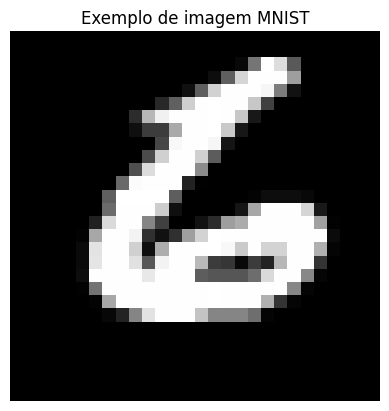

In [3]:
import idx2numpy
import matplotlib.pyplot as plt

# Carregar as imagens do arquivo MNIST
file_path = 'numbers/t10k-images.idx3-ubyte'
images = idx2numpy.convert_from_file(file_path)

# Verificar formato
print(images.shape)  # Deve ser (10000, 28, 28)

# Escolher uma imagem (ex.: índice 0)
img = images[9999]

# Plotar a imagem
plt.imshow(img, cmap='gray')
plt.title('Exemplo de imagem MNIST')
plt.axis('off')
plt.show()


In [4]:
# 10k images (greyscale)

images.shape

(10000, 28, 28)

In [5]:
import numpy as np


# Aplica padding de 2 pixels em cima, baixo, esquerda e direita
images_padded = np.pad(images, pad_width=((0, 0), (2, 2), (2, 2)), mode='constant', constant_values=0)

print(images_padded.shape)  # Deve ser (10000, 32, 32)

(10000, 32, 32)


In [6]:
# Caminho do arquivo
file_path = 'numbers/t10k-labels.idx1-ubyte'

# Carregar labels como array NumPy
labels = idx2numpy.convert_from_file(file_path)

print(labels.shape)  # Deve ser (10000,)

(10000,)


# Learning LeNet-5
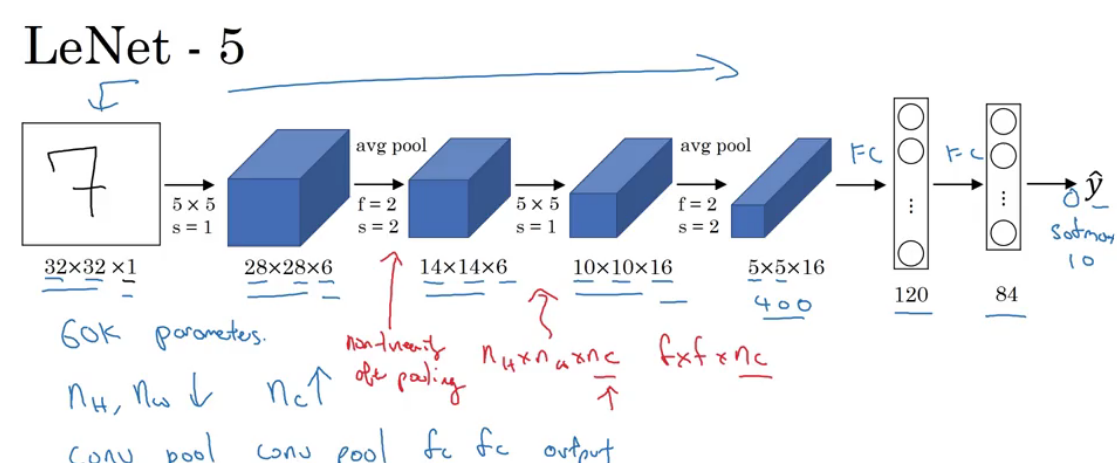

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

# Modelo sequencial
model = Sequential([
    Conv2D(6, (5, 5), activation='tanh', input_shape=(32, 32, 1)),
    AveragePooling2D((2, 2)),
    Conv2D(16, (5, 5), activation='tanh'),
    AveragePooling2D((2, 2)),
    Flatten(),
    Dense(120, activation='tanh'),
    Dense(84, activation='tanh'),
    Dense(10, activation='softmax')
])

C:\Users\marcio.lourenco.CONECTCAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 6)           │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d (AveragePooling2D) │ (None, 14, 14, 6)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 10, 10, 16)          │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_1                  │ (None, 5, 5, 16)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 120)                 │          48,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## Treino e Teste (Split)

In [10]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

images = images_padded.astype('float32') / 255.0
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)

print(X_train.shape, X_test.shape)

(8000, 32, 32) (2000, 32, 32)


In [11]:
# One-hot encoding dos rótulos
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.1)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7275 - loss: 0.9741 - val_accuracy: 0.8550 - val_loss: 0.4807
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9003 - loss: 0.3585 - val_accuracy: 0.8913 - val_loss: 0.3649
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9190 - loss: 0.2807 - val_accuracy: 0.9187 - val_loss: 0.3068
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9329 - loss: 0.2259 - val_accuracy: 0.9262 - val_loss: 0.2710
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9426 - loss: 0.1901 - val_accuracy: 0.9350 - val_loss: 0.2305
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9540 - loss: 0.1587 - val_accuracy: 0.9388 - val_loss: 0.2126
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9608 - loss: 0.1333 - val_accuracy: 0.9400 - val_loss: 0.1998
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9649 - loss: 0.1183 - val_accuracy: 0.9463 - v

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Acurácia no teste: {test_acc:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9575 - loss: 0.1279
Acurácia no teste: 0.9575


## AlexNet

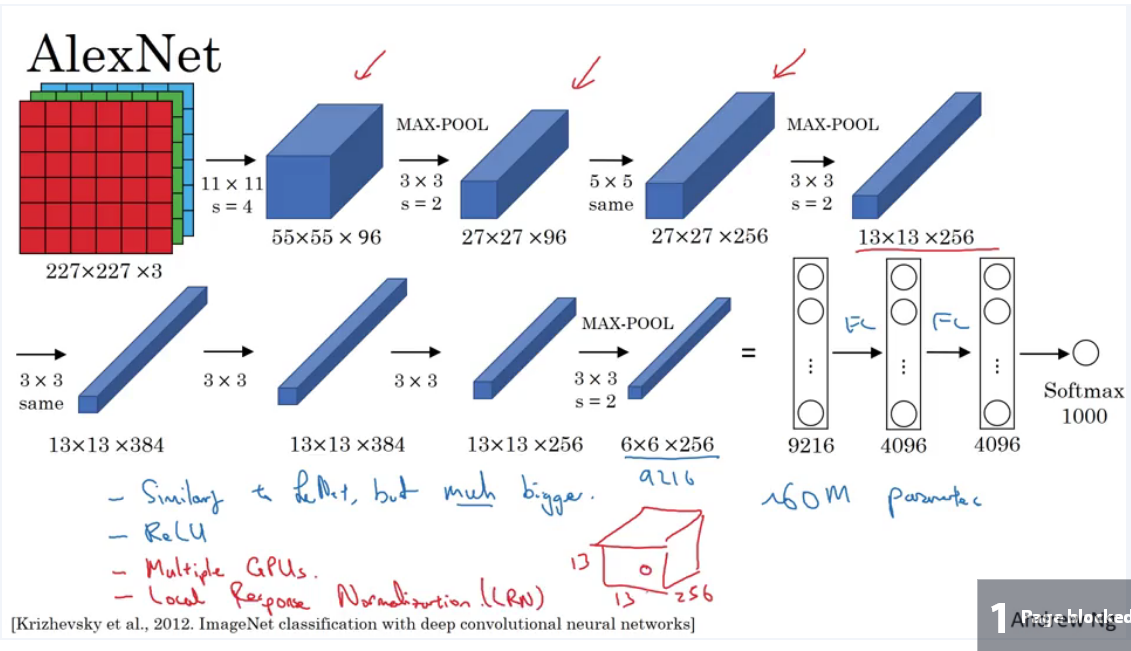

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD

model = Sequential([
    # Conv1
    Conv2D(96, (11, 11), strides=(4, 4), padding='valid',
           activation='relu', kernel_initializer='he_normal',
           input_shape=(227, 227, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    # Conv2 (com groups=2 opcional)
    Conv2D(256, (5, 5), padding='same',
           activation='relu', kernel_initializer='he_normal', groups=1),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    # Conv3
    Conv2D(384, (3, 3), padding='same',
           activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),

    # Conv4
    Conv2D(384, (3, 3), padding='same',
           activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),

    # Conv5
    Conv2D(256, (3, 3), padding='same',
           activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    Flatten(),

    # FCs com Dropout
    Dense(4096, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.5),
    Dense(4096, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.5),

    Dense(1000, activation='softmax')
])

# Otimizador clássico (momentum)
model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [7]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 55, 55, 96)          │          34,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 55, 55, 96)          │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 27, 27, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 27, 27, 256)         │         614,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 27, 27, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 13, 13, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 13, 13, 384)         │         885,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 13, 13, 384)         │           1,536 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 13, 13, 384)         │       1,327,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 13, 13, 384)         │           1,536 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 13, 13, 256)         │         884,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 13, 13, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 4096)                │      37,752,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 4096)                │      16,781,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1000)                │       4,097,0

 Total params: 62,383,848 (237.98 MB)

 Trainable params: 62,381,096 (237.96 MB)

 Non-trainable params: 2,752 (10.75 KB)

## VGG 16
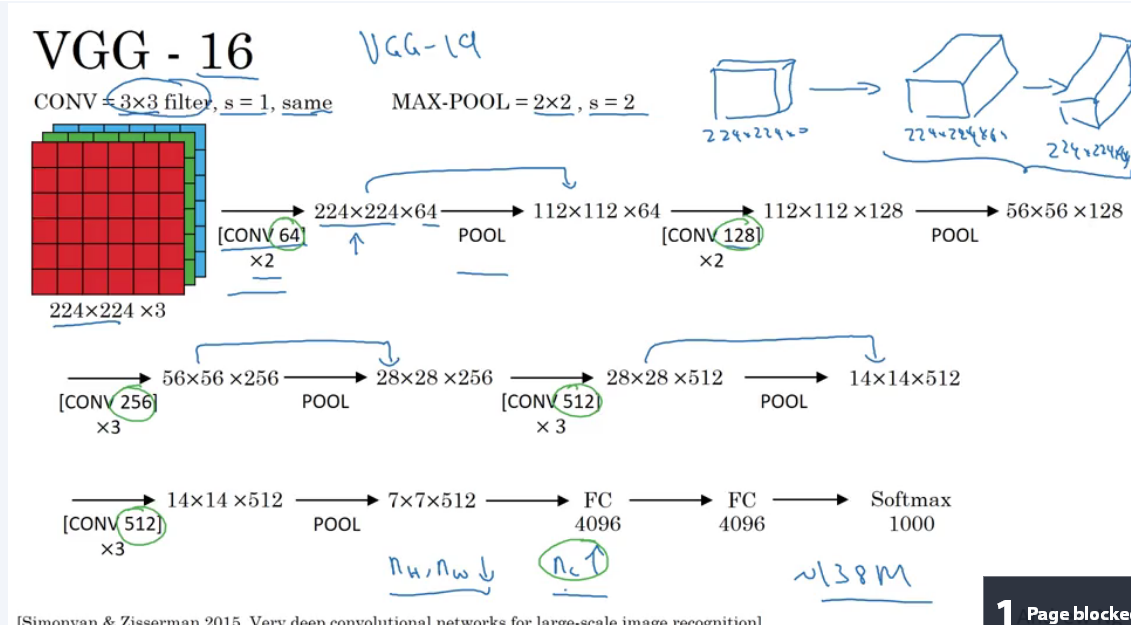

In [8]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import SGD

# Entrada padrão para VGG16
input_shape = (224, 224, 3)
num_classes = 1000  # ajuste para seu dataset

model = Sequential([
    # Bloco 1
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=input_shape),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2), strides=(2,2)),

    # Bloco 2
    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2), strides=(2,2)),

    # Bloco 3
    Conv2D(256, (3,3), activation='relu', padding='same'),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2), strides=(2,2)),

    # Bloco 4
    Conv2D(512, (3,3), activation='relu', padding='same'),
    Conv2D(512, (3,3), activation='relu', padding='same'),
    Conv2D(512, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2), strides=(2,2)),

    # Bloco 5
    Conv2D(512, (3,3), activation='relu', padding='same'),
    Conv2D(512, (3,3), activation='relu', padding='same'),
    Conv2D(512, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2), strides=(2,2)),

    # Classificador
    Flatten(),
    Dense(4096, activation='relu'),
    Dense(4096, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Otimizador clássico
model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)                   │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_21 (Conv2D)                   │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_24 (Conv2D)                   │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 4096)                │      16,781,312 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

## Residual Block (ResNet)
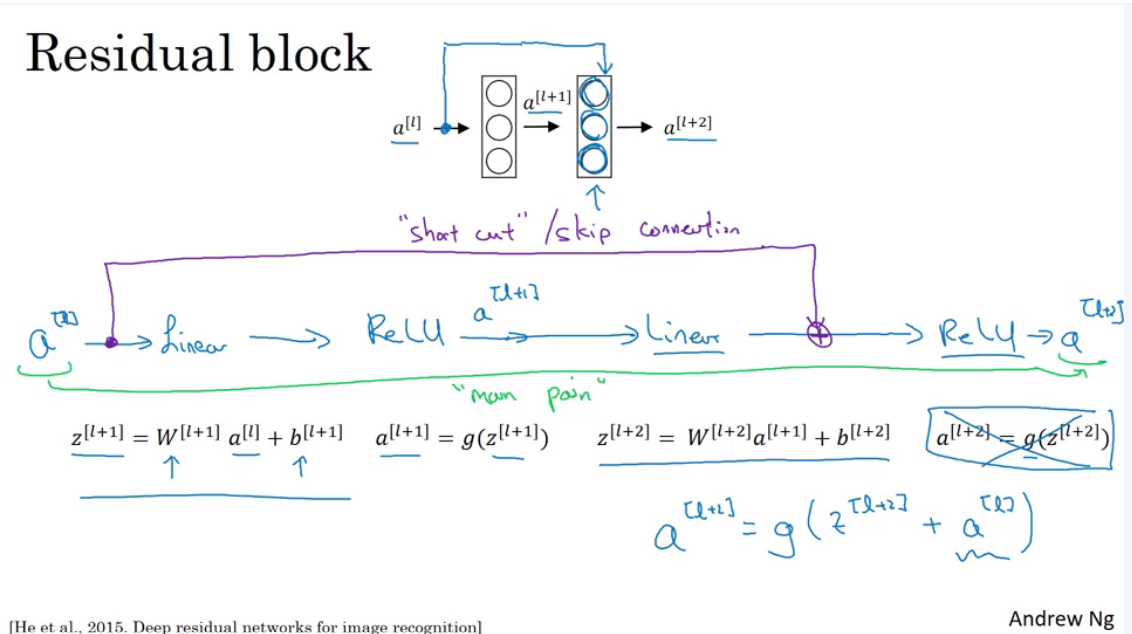

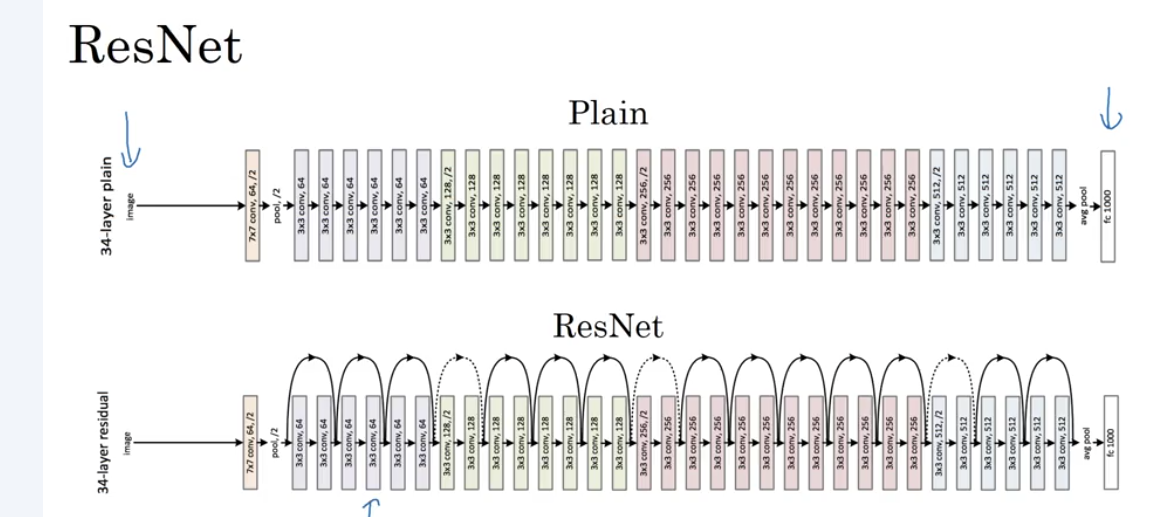

In [2]:
## Exemplo simples

import numpy as np

def relu(x):
    return np.maximum(0, x)

class ResidualBlock:
    def __init__(self, dim):
        # Parâmetros bem simples
        self.W1 = np.random.randn(dim, dim) * 0.1
        self.b1 = np.zeros((1, dim))
        self.W2 = np.random.randn(dim, dim) * 0.1
        self.b2 = np.zeros((1, dim))

    def F(self, x):
        return relu(x @ self.W1 + self.b1) @ self.W2 + self.b2

    def forward(self, x):
        return x + self.F(x)  # skip connection

# Exemplo de uso
np.random.seed(0)
x = np.random.randn(5, 4)        # batch=5, dimensão=4
block = ResidualBlock(dim=4)
y = block.forward(x)
print("Entrada (x):\n", x)
print("Saída residual (y = x + F(x)):\n", y)

Entrada (x):
 [[ 1.76405235  0.40015721  0.97873798  2.2408932 ]
 [ 1.86755799 -0.97727788  0.95008842 -0.15135721]
 [-0.10321885  0.4105985   0.14404357  1.45427351]
 [ 0.76103773  0.12167502  0.44386323  0.33367433]
 [ 1.49407907 -0.20515826  0.3130677  -0.85409574]]
Saída residual (y = x + F(x)):
 [[ 1.7593878   0.39614778  0.9672719   2.2480091 ]
 [ 1.81305517 -1.04662758  0.85390481 -0.05297812]
 [-0.10622344  0.41150456  0.14103714  1.45498458]
 [ 0.75462908  0.11454944  0.43082566  0.34454561]
 [ 1.44985182 -0.26094947  0.2342053  -0.77459186]]


## 1 x 1 Convolution
- Redução de Dimensionalidade (ou aumento controlado)
- Eficiência Computacional
- Introdução de Não-Linearidade
- Mistura de Informações entre Canais

Cada saída é uma combinação linear dos canais de entrada, permitindo aprender interações entre features sem alterar a posição dos pixels.
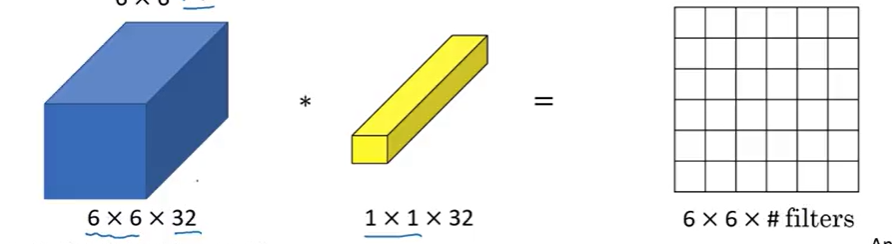

In [12]:
# Dimensões
H, W, C_in = 6, 6, 32
num_filters = 4

# Entrada simulada
np.random.seed(0)
x = np.random.randn(H, W, C_in)  # (6, 6, 32)

# Pesos do kernel 1x1
W = np.random.randn(C_in, num_filters) * 0.1  # (32, 8)
b = np.zeros((num_filters,))  # (8,)

# Convolução 1x1 com broadcasting
out = x @ W + b  # (6, 6, 8)

# Aplica ReLU
out = np.maximum(0, out)

print("Shape da saída:", out.shape)  # (6, 6, 8)
out[0, 0]

Shape da saída: (6, 6, 4)


array([0.42815567, 0.        , 0.        , 1.48206168])

## Inception Network
- Multiple Operations in a single layer
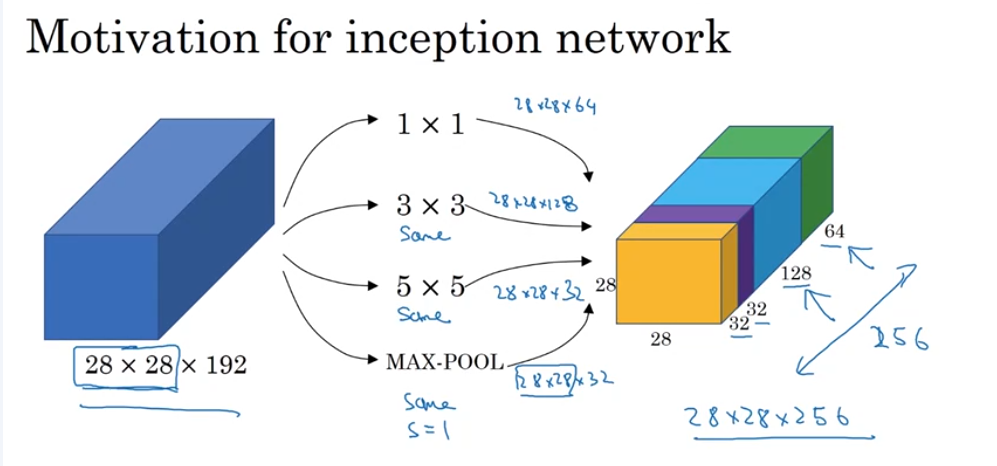

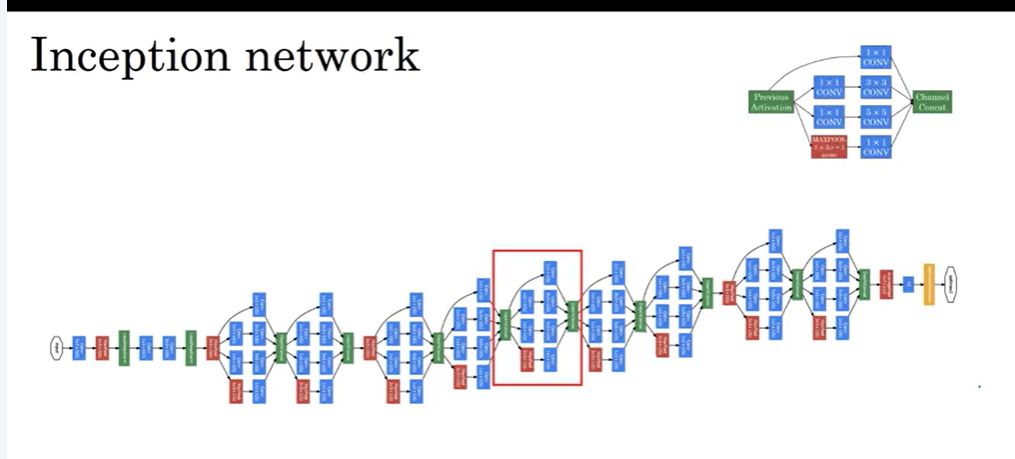

## MobileNet - Leve para celular (menos parametros)
- 31% mais barato computacionalmente usar MobileNet
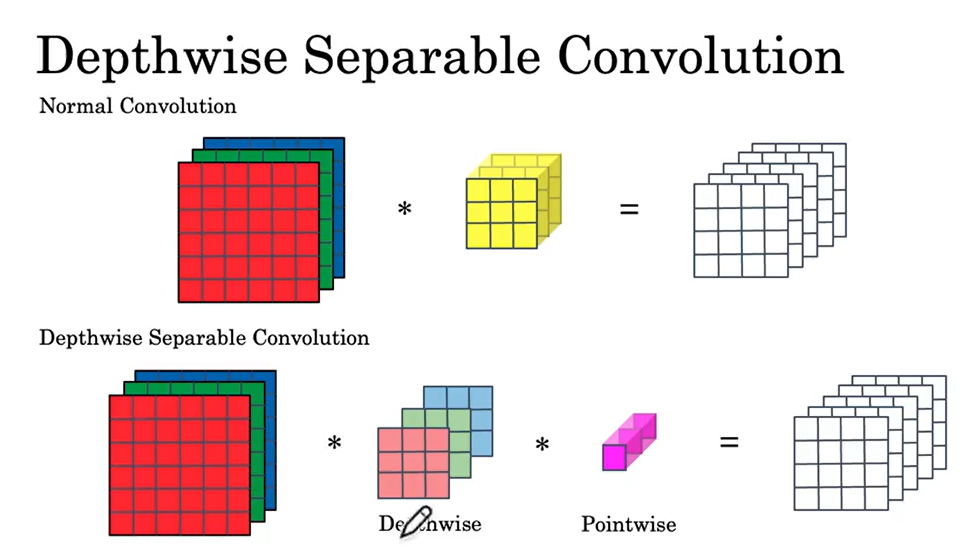

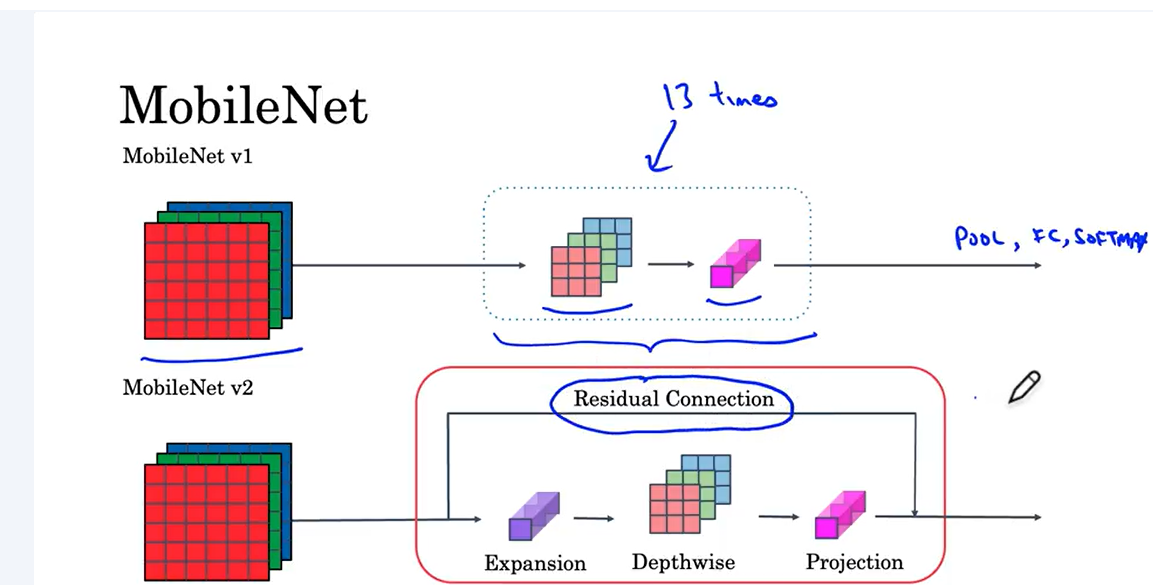

## EficientNet

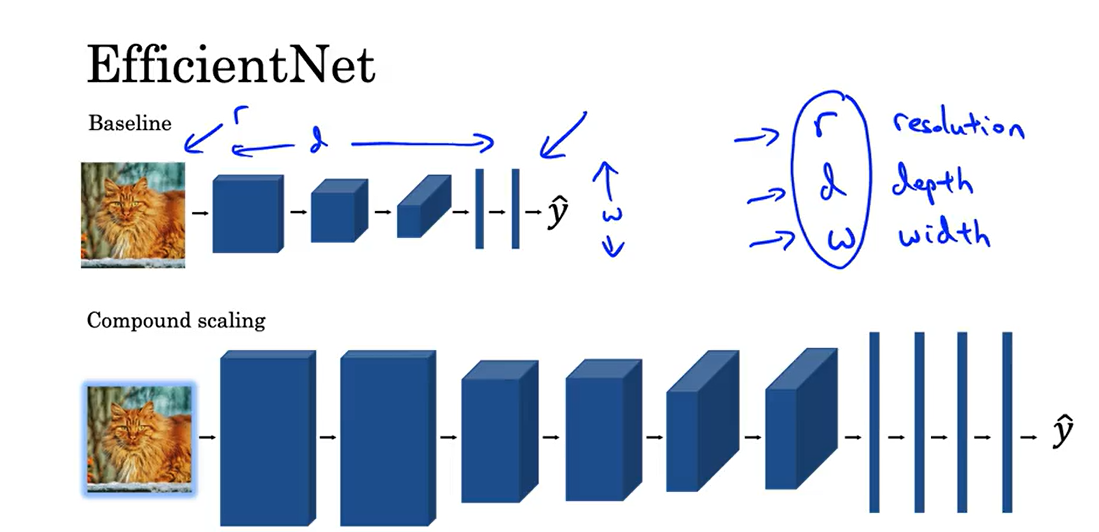